# LTSA epsilon with analytical PCA asymptotic-onset reference

Figure layout:

- one row, three columns: trials, neurons, animals;
- each panel shows LTSA for `k = 10, 15, 20`;
- colored dashed lines: LTSA asymptotic-regime onsets, still fitted from LTSA curves;
- black dashed line: analytical PCA epsilon asymptotic-regime onset from `pcalib.functions`.


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

from pcalib.classes import Potential
from pcalib.functions import (
    asymptotic_regime_trials,
    asymptotic_regime_neurons,
    asymptotic_regime_animals,
)

## Load cached results

In [9]:
OUT = Path.cwd() / "cached_results"


def load_array(name):
    return np.load(OUT / name)


potential_init = Potential.from_npz(OUT / "potential_init.npz")
signal_init = load_array("signal_init.npy")

trials_grid = load_array("trials_grid.npy")
neurons_grid = load_array("neurons_grid.npy")
animals_grid = load_array("animals_grid.npy")
n_neighbors_grid = load_array("n_neighbors_grid.npy").astype(int)

pca_epsilon_trials = load_array("pca_epsilon_trials.npy")
ltsa_epsilon_trials = load_array("ltsa_epsilon_trials.npy")
ltsa_local_varx_trials = load_array("ltsa_local_varx_trials.npy")

pca_epsilon_neurons = load_array("pca_epsilon_neurons.npy")
ltsa_epsilon_neurons = load_array("ltsa_epsilon_neurons.npy")
ltsa_local_varx_neurons = load_array("ltsa_local_varx_neurons.npy")

pca_epsilon_animals = load_array("pca_epsilon_animals.npy")
ltsa_epsilon_animals = load_array("ltsa_epsilon_animals.npy")
ltsa_local_varx_animals = load_array("ltsa_local_varx_animals.npy")

selected_k = np.array([10, 15, 20])
selected_k_idx = []

for k in selected_k:
    idx = np.where(n_neighbors_grid == k)[0]
    if len(idx) == 0:
        raise ValueError(f"k={k} is not present in n_neighbors_grid={n_neighbors_grid}")
    selected_k_idx.append(idx[0])

selected_k_idx = np.array(selected_k_idx)
n_trials0 = int(trials_grid[0])

print("n_neighbors_grid:", n_neighbors_grid)
print("selected k:", selected_k)
print("initial number of trials:", n_trials0)
print("LTSA trials shape:", ltsa_epsilon_trials.shape)
print("LTSA neurons shape:", ltsa_epsilon_neurons.shape)
print("LTSA animals shape:", ltsa_epsilon_animals.shape)

n_neighbors_grid: [10 15 20]
selected k: [10 15 20]
initial number of trials: 5
LTSA trials shape: (3, 10, 30)
LTSA neurons shape: (3, 11, 30)
LTSA animals shape: (3, 10, 30)


## Fitting helpers

In [10]:
def mean_and_std(values, axis=-1):
    values = np.asarray(values)
    return np.nanmean(values, axis=axis), np.nanstd(values, axis=axis)


def power_law_with_offset(x, a, b, c):
    return a * np.asarray(x, dtype=float) ** b + c


def fit_power_law_with_offset(grid, mean):
    grid = np.asarray(grid, dtype=float)
    mean = np.asarray(mean, dtype=float)

    valid = np.isfinite(grid) & np.isfinite(mean) & (grid > 0)
    x, y = grid[valid], mean[valid]

    if len(x) < 3:
        return None

    p0 = (y[0] - y[-1], -1.0, y[-1])

    try:
        popt, _ = curve_fit(
            power_law_with_offset,
            x,
            y,
            p0=p0,
            maxfev=20000,
        )
        return popt
    except (RuntimeError, ValueError, FloatingPointError):
        return None


def asymptote_from_fit(popt, reference_scale):
    """
    Return x such that |a| x^b = reference_scale.

    The fit is y = a x^b + c. The quantity |a| x^b is interpreted as
    the remaining finite-size correction to the fitted asymptote c.
    """
    if popt is None:
        return np.nan

    a, b, _ = popt

    if not np.isfinite(a) or not np.isfinite(b):
        return np.nan
    if a == 0 or b == 0 or reference_scale <= 0:
        return np.nan

    x = (reference_scale / abs(a)) ** (1 / b)

    if np.isfinite(x) and x > 0:
        return x

    return np.nan


def ltsa_reference_scale(local_varx, k_idx, fraction=0.01):
    return fraction * np.nanmean(local_varx[k_idx])


def scalar_onset(x):
    """Collapse per-component analytical onsets to one scalar line."""
    return float(np.nanmean(np.asarray(x, dtype=float)))

## Analytical PCA asymptotic onsets

In [11]:
def analytical_pca_onsets(pot, n_trials):
    _, eps_trials = asymptotic_regime_trials(
        pot,
        n_trials=n_trials,
        delta_epsilon=0.01,
    )

    _, eps_neurons = asymptotic_regime_neurons(
        pot,
        n_trials=n_trials,
        delta_epsilon=0.01,
    )

    _, eps_animals = asymptotic_regime_animals(
        pot,
        n_trials=n_trials,
        delta_epsilon=0.01,
    )

    return {
        "trials": scalar_onset(eps_trials),
        "neurons": scalar_onset(eps_neurons),
        "animals": scalar_onset(eps_animals),
    }


pca_onsets = analytical_pca_onsets(potential_init, n_trials=n_trials0)
pca_onsets

[4. 2.]
2.999999999999997
epsilon_1= 0.04859771223547604
sigma true: 1.2074482875321333
sigma^2 usual: 0.00971954244709521
var(x): [4. 2.]
R_inf: [0.99981781 0.99963572]
R_1: [-1.32823538e-05 -5.31197391e-05]
Epsilon_inf: [1.32823536e-07 2.65598687e-07]
Epsilon_1: [0.29179885 0.29201146]


{'trials': 1.6199237411825362,
 'neurons': 10.947772205733928,
 'animals': 0.36492574019113094}

## Plotting helpers

In [12]:
cmap = plt.get_cmap("viridis")
k_colors = cmap(np.linspace(0.15, 0.85, len(selected_k)))


def add_vertical_line(ax, x_value, color, label, linestyle="--", linewidth=1.5, alpha=0.85):
    if not np.isfinite(x_value):
        return

    ax.axvline(
        x_value,
        linestyle=linestyle,
        linewidth=linewidth,
        color=color,
        alpha=alpha,
        label=label,
    )


def plot_ltsa_panel(ax, grid, ltsa_values, local_varx, pca_onset_value, title, xlabel):
    for color, k, k_idx in zip(k_colors, selected_k, selected_k_idx):
        mean, std = mean_and_std(ltsa_values[k_idx], axis=1)

        ax.errorbar(
            grid,
            mean,
            yerr=std,
            fmt="o-",
            capsize=3,
            color=color,
            ecolor=color,
            label=fr"LTSA $k={k}$",
        )

        popt = fit_power_law_with_offset(grid, mean)
        x_ltsa = asymptote_from_fit(
            popt,
            reference_scale=ltsa_reference_scale(local_varx, k_idx),
        )

        #add_vertical_line(ax, x_ltsa, color=color, label=fr"LTSA onset $k={k}$",)

    '''
    add_vertical_line(
        ax,
        pca_onset_value,
        color="black",
        label="PCA analytical onset",
        linestyle="--",
        linewidth=2.0,
        alpha=0.9,
    )
    '''

    #ax.set_title(title)
    ax.set_xlim(0, grid.max())
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"LTSA $\epsilon$")
    ax.legend(fontsize=7)


def add_panel_label(ax, label):
    ax.text(
        -0.12,
        1.08,
        label,
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        va="top",
        ha="left",
    )

## Main figure

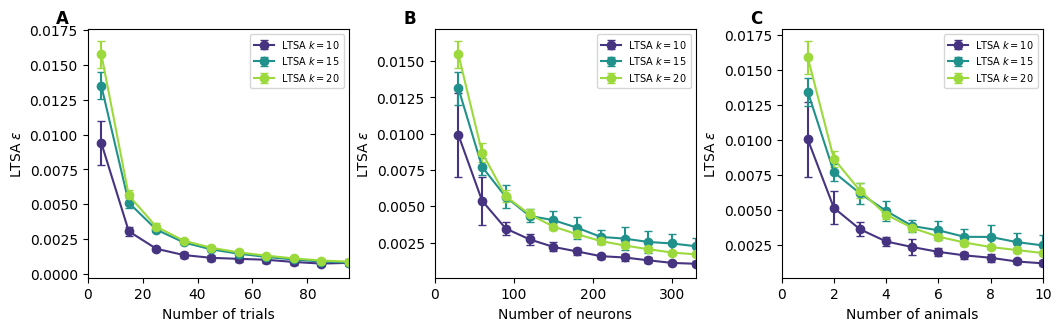

In [13]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(10.5, 3.2),
    constrained_layout=True,
)

columns = [
    (
        "Trials",
        trials_grid,
        ltsa_epsilon_trials,
        ltsa_local_varx_trials,
        pca_onsets["trials"],
        "Number of trials",
    ),
    (
        "Neurons",
        neurons_grid,
        ltsa_epsilon_neurons,
        ltsa_local_varx_neurons,
        pca_onsets["neurons"],
        "Number of neurons",
    ),
    (
        "Animals",
        animals_grid,
        ltsa_epsilon_animals,
        ltsa_local_varx_animals,
        pca_onsets["animals"],
        "Number of animals",
    ),
]

for ax, (title, grid, ltsa_values, local_varx, pca_onset_value, xlabel) in zip(axes, columns):
    plot_ltsa_panel(
        ax,
        grid=grid,
        ltsa_values=ltsa_values,
        local_varx=local_varx,
        pca_onset_value=pca_onset_value,
        title=title,
        xlabel=xlabel,
    )

for ax, label in zip(axes, list("ABC")):
    add_panel_label(ax, label)

fig.savefig(
    OUT / "fig6.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

## Print inferred onset values

In [14]:
def ltsa_onsets(grid, ltsa_values, local_varx):
    values = {}

    for k, k_idx in zip(selected_k, selected_k_idx):
        mean, _ = mean_and_std(ltsa_values[k_idx], axis=1)
        popt = fit_power_law_with_offset(grid, mean)
        values[int(k)] = asymptote_from_fit(
            popt,
            reference_scale=ltsa_reference_scale(local_varx, k_idx),
        )

    return values


print("LTSA fitted onset estimates")
print("trials:", ltsa_onsets(trials_grid, ltsa_epsilon_trials, ltsa_local_varx_trials))
print("neurons:", ltsa_onsets(neurons_grid, ltsa_epsilon_neurons, ltsa_local_varx_neurons))
print("animals:", ltsa_onsets(animals_grid, ltsa_epsilon_animals, ltsa_local_varx_animals))

print()
print("PCA analytical epsilon onset estimates")
print(pca_onsets)

LTSA fitted onset estimates
trials: {10: np.float64(28.76841749851279), 15: np.float64(39.88502357692179), 20: np.float64(25.289083291378716)}
neurons: {10: np.float64(311.24627938643306), 15: np.float64(237.7112566587908), 20: np.float64(181.2933459295137)}
animals: {10: np.float64(8.634542796010747), 15: np.float64(9.012242811491532), 20: np.float64(6.765862501256036)}

PCA analytical epsilon onset estimates
{'trials': 1.6199237411825362, 'neurons': 10.947772205733928, 'animals': 0.36492574019113094}
